# Healthcare Provider Fraud Detection — Engineering Version

This notebook builds a reproducible provider-level healthcare fraud risk model using the project's four original CSV datasets. It adds validation, model comparison, train/validation/test separation, threshold selection, explainability, and a production model artifact.

**Interpretation:** the model identifies providers associated with historical patterns of potential fraud; it does not establish factual or legal fraud.


In [42]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
print("Libraries imported successfully.")


Libraries imported successfully.


In [43]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)


Project root: /Users/anupgouda/Desktop/Healthcare-Fraud-Detection
Data directory: /Users/anupgouda/Desktop/Healthcare-Fraud-Detection/data
Model directory: /Users/anupgouda/Desktop/Healthcare-Fraud-Detection/models


In [44]:
required_files = {
    "train": DATA_DIR / "Train-1542865627584.csv",
    "beneficiary": DATA_DIR / "Train_Beneficiarydata-1542865627584.csv",
    "inpatient": DATA_DIR / "Train_Inpatientdata-1542865627584.csv",
    "outpatient": DATA_DIR / "Train_Outpatientdata-1542865627584.csv",
}
missing_files = [str(p) for p in required_files.values() if not p.exists()]
if missing_files:
    raise FileNotFoundError("Missing required dataset files:\n" + "\n".join(missing_files))
print("All required dataset files found.")
for name, path in required_files.items(): print(f"{name:12} -> {path.name}")


All required dataset files found.
train        -> Train-1542865627584.csv
beneficiary  -> Train_Beneficiarydata-1542865627584.csv
inpatient    -> Train_Inpatientdata-1542865627584.csv
outpatient   -> Train_Outpatientdata-1542865627584.csv


In [45]:
train = pd.read_csv(required_files["train"])
beneficiary = pd.read_csv(required_files["beneficiary"])
inpatient = pd.read_csv(required_files["inpatient"])
outpatient = pd.read_csv(required_files["outpatient"])
print("Datasets loaded successfully.")
print("Train:", train.shape)
print("Beneficiary:", beneficiary.shape)
print("Inpatient:", inpatient.shape)
print("Outpatient:", outpatient.shape)


Datasets loaded successfully.
Train: (5410, 2)
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)


In [46]:
display(train.head())
display(beneficiary.head())
display(inpatient.head())
display(outpatient.head())


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [47]:
def data_quality_report(df, name):
    report = pd.DataFrame({"column":df.columns,"dtype":df.dtypes.astype(str).values,"missing":df.isnull().sum().values,"missing_%":(df.isnull().mean().values*100).round(2),"unique":df.nunique().values})
    print(f"\n{name}")
    display(report.sort_values("missing_%", ascending=False).head(20))
for df, name in [(train,"TRAIN"),(beneficiary,"BENEFICIARY"),(inpatient,"INPATIENT"),(outpatient,"OUTPATIENT")]: data_quality_report(df,name)
print("\nDuplicate records:")
print("Train:",train.duplicated().sum()," Beneficiary:",beneficiary.duplicated().sum()," Inpatient:",inpatient.duplicated().sum()," Outpatient:",outpatient.duplicated().sum())



TRAIN


,column,dtype,missing,missing_%,unique
0,Provider,str,0,0.0,5410
1,PotentialFraud,str,0,0.0,2



BENEFICIARY


,column,dtype,missing,missing_%,unique
2,DOD,str,137135,98.97,11
0,BeneID,str,0,0.00,138556
13,ChronicCond_Cancer,int64,0,0.00,2
23,OPAnnualReimbursementAmt,int64,0,0.00,2078
22,IPAnnualDeductibleAmt,int64,0,0.00,147
21,IPAnnualReimbursementAmt,int64,0,0.00,3004
20,ChronicCond_stroke,int64,0,0.00,2
19,ChronicCond_rheumatoidarthritis,int64,0,0.00,2
18,ChronicCond_Osteoporasis,int64,0,0.00,2
17,ChronicCond_IschemicHeart,int64,0,0.00,2



INPATIENT


,column,dtype,missing,missing_%,unique
29,ClmProcedureCode_6,float64,40474,100.00,0
28,ClmProcedureCode_5,float64,40465,99.98,6
27,ClmProcedureCode_4,float64,40358,99.71,48
26,ClmProcedureCode_3,float64,39509,97.62,154
23,ClmDiagnosisCode_10,str,36547,90.30,952
8,OtherPhysician,str,35784,88.41,2877
25,ClmProcedureCode_2,float64,35020,86.52,297
24,ClmProcedureCode_1,float64,17326,42.81,1117
7,OperatingPhysician,str,16644,41.12,8287
22,ClmDiagnosisCode_9,str,13497,33.35,2094



OUTPATIENT


,column,dtype,missing,missing_%,unique
24,ClmProcedureCode_6,float64,517737,100.00,0
23,ClmProcedureCode_5,float64,517737,100.00,0
22,ClmProcedureCode_4,float64,517735,100.00,2
21,ClmProcedureCode_3,float64,517733,100.00,4
20,ClmProcedureCode_2,float64,517701,99.99,22
19,ClmProcedureCode_1,float64,517575,99.97,80
18,ClmDiagnosisCode_10,str,516654,99.79,495
17,ClmDiagnosisCode_9,str,502899,97.13,1894
16,ClmDiagnosisCode_8,str,494825,95.57,2260
15,ClmDiagnosisCode_7,str,484776,93.63,2635



Duplicate records:
Train: 0  Beneficiary: 0  Inpatient: 0  Outpatient: 0


In [48]:
beneficiary["DOB"] = pd.to_datetime(beneficiary["DOB"], errors="coerce")
beneficiary["DOD"] = pd.to_datetime(beneficiary["DOD"], errors="coerce")
for c in ["ClaimStartDt","ClaimEndDt","AdmissionDt","DischargeDt"]: inpatient[c] = pd.to_datetime(inpatient[c], errors="coerce")
for c in ["ClaimStartDt","ClaimEndDt"]: outpatient[c] = pd.to_datetime(outpatient[c], errors="coerce")
claims = pd.concat([inpatient,outpatient], ignore_index=True)
claims = claims.merge(beneficiary,on="BeneID",how="left")
print("Claims shape after merge:",claims.shape)


Claims shape after merge: (558211, 54)


In [49]:
claims["Age"] = claims["ClaimStartDt"].dt.year - claims["DOB"].dt.year
claims["ClaimDuration"] = (claims["ClaimEndDt"]-claims["ClaimStartDt"]).dt.days
claims["HospitalStay"] = (claims["DischargeDt"]-claims["AdmissionDt"]).dt.days
chronic_columns=["ChronicCond_Alzheimer","ChronicCond_Heartfailure","ChronicCond_KidneyDisease","ChronicCond_Cancer","ChronicCond_ObstrPulmonary","ChronicCond_Depression","ChronicCond_Diabetes","ChronicCond_IschemicHeart","ChronicCond_Osteoporasis","ChronicCond_rheumatoidarthritis","ChronicCond_stroke"]
claims["ChronicCount"]=(claims[chronic_columns]==1).sum(axis=1)
claims["Dead"]=claims["DOD"].notnull()
print("Feature engineering completed.")


Feature engineering completed.


In [50]:
provider_features=claims.groupby("Provider").agg({"InscClaimAmtReimbursed":["sum","mean","max","min"],"DeductibleAmtPaid":["sum","mean"],"ClaimID":"count","Age":["mean","max"],"HospitalStay":["mean","max"],"ClaimDuration":["mean","max"],"ChronicCount":["mean","sum"],"Dead":"sum"})
provider_features.columns=["_".join(c) for c in provider_features.columns]
provider_features.reset_index(inplace=True)
dataset=provider_features.merge(train,on="Provider",how="left")
dataset["PotentialFraud"]=dataset["PotentialFraud"].replace({"Yes":1,"No":0})
print("Provider feature dataset:",provider_features.shape)
print("Final modeling dataset:",dataset.shape)
display(dataset.head())


Provider feature dataset: (5410, 17)
Final modeling dataset: (5410, 18)


,Provider,InscClaimAmtReimbursed_sum,InscClaimAmtReimbursed_mean,InscClaimAmtReimbursed_max,InscClaimAmtReimbursed_min,DeductibleAmtPaid_sum,DeductibleAmtPaid_mean,ClaimID_count,Age_mean,Age_max,HospitalStay_mean,HospitalStay_max,ClaimDuration_mean,ClaimDuration_max,ChronicCount_mean,ChronicCount_sum,Dead_sum,PotentialFraud
0,PRV51001,104640,4185.600000,42000,10,5340.0,213.600000,25,78.280000,98,5.000000,14.0,1.440000,14,5.560000,139,0,0
1,PRV51003,605670,4588.409091,57000,0,66286.0,502.166667,132,69.545455,97,5.161290,27.0,3.674242,27,4.545455,600,1,1
2,PRV51004,52170,350.134228,3300,0,310.0,2.080537,149,71.812081,100,NaN,NaN,1.429530,20,4.342282,647,1,0
3,PRV51005,280910,241.124464,4080,0,3700.0,3.175966,1165,69.999142,100,NaN,NaN,1.088412,20,4.335622,5051,4,1
4,PRV51007,33710,468.194444,10000,0,3264.0,45.333333,72,68.791667,99,5.333333,7.0,0.958333,20,4.166667,300,1,0


Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64

Target percentage:
PotentialFraud
0    90.65
1     9.35
Name: proportion, dtype: float64


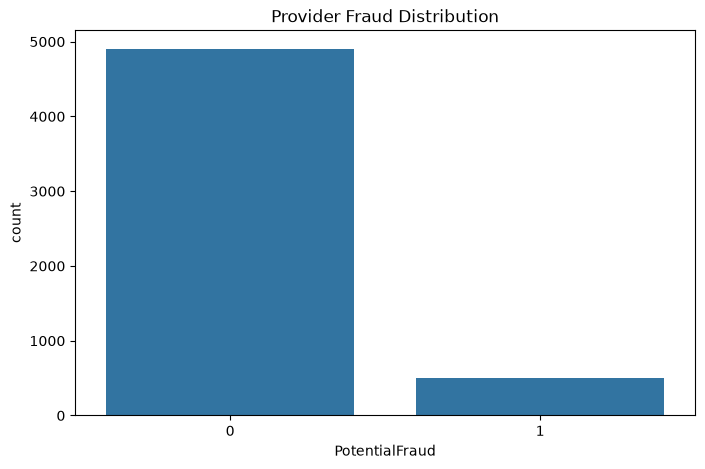

In [51]:
print("Target distribution:")
print(dataset["PotentialFraud"].value_counts())
print("\nTarget percentage:")
print(dataset["PotentialFraud"].value_counts(normalize=True).mul(100).round(2))
plt.figure(figsize=(8,5)); sns.countplot(x="PotentialFraud",data=dataset); plt.title("Provider Fraud Distribution"); plt.show()


In [52]:
X=dataset.drop(columns=["Provider","PotentialFraud"])
y=dataset["PotentialFraud"].astype(int)
X=X.select_dtypes(include=[np.number]).replace([np.inf,-np.inf],np.nan).fillna(0)
print("Feature matrix:",X.shape)
print("Target:",y.shape)
print("Features:",list(X.columns))


Feature matrix: (5410, 16)
Target: (5410,)
Features: ['InscClaimAmtReimbursed_sum', 'InscClaimAmtReimbursed_mean', 'InscClaimAmtReimbursed_max', 'InscClaimAmtReimbursed_min', 'DeductibleAmtPaid_sum', 'DeductibleAmtPaid_mean', 'ClaimID_count', 'Age_mean', 'Age_max', 'HospitalStay_mean', 'HospitalStay_max', 'ClaimDuration_mean', 'ClaimDuration_max', 'ChronicCount_mean', 'ChronicCount_sum', 'Dead_sum']


In [53]:
X_dev,X_test,y_dev,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
X_train,X_val,y_train,y_val=train_test_split(X_dev,y_dev,test_size=0.20,random_state=42,stratify=y_dev)
print("X_train:",X_train.shape)
print("X_val  :",X_val.shape)
print("X_test :",X_test.shape)


X_train: (3462, 16)
X_val  : (866, 16)
X_test : (1082, 16)


In [54]:
def evaluate_model(name,model,X_eval,y_eval):
    pred=model.predict(X_eval); prob=model.predict_proba(X_eval)[:,1]
    return {"Model":name,"Accuracy":accuracy_score(y_eval,pred),"Precision":precision_score(y_eval,pred,zero_division=0),"Recall":recall_score(y_eval,pred,zero_division=0),"F1":f1_score(y_eval,pred,zero_division=0),"ROC_AUC":roc_auc_score(y_eval,prob),"PR_AUC":average_precision_score(y_eval,prob)}
log_model=LogisticRegression(max_iter=1000,random_state=42).fit(X_train,y_train)
rf_model=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,n_jobs=-1).fit(X_train,y_train)
xgb_model=XGBClassifier(random_state=42,n_estimators=500,max_depth=7,learning_rate=0.05,eval_metric="logloss").fit(X_train,y_train)
lgb_model=LGBMClassifier(random_state=42,n_estimators=500,verbosity=-1).fit(X_train,y_train)
results=pd.DataFrame([evaluate_model("Logistic Regression",log_model,X_val,y_val),evaluate_model("Random Forest",rf_model,X_val,y_val),evaluate_model("XGBoost",xgb_model,X_val,y_val),evaluate_model("LightGBM",lgb_model,X_val,y_val)])
display(results.style.format({c:"{:.4f}" for c in results.columns if c!="Model"}))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9388,0.7593,0.5062,0.6074,0.9314,0.6544
1,Random Forest,0.9330,0.6825,0.5309,0.5972,0.9256,0.6498
2,XGBoost,0.9284,0.6462,0.5185,0.5753,0.9193,0.5999
3,LightGBM,0.9203,0.5968,0.4568,0.5175,0.9091,0.6033


In [55]:
param_grid={"n_estimators":[200,300],"max_depth":[5,10],"min_samples_split":[2,5]}
rf_base=RandomForestClassifier(random_state=42,n_jobs=-1)
grid_search=GridSearchCV(estimator=rf_base,param_grid=param_grid,scoring="f1",cv=5,n_jobs=-1,verbose=1)
grid_search.fit(X_train,y_train)
print("Best parameters:"); print(grid_search.best_params_)
print("\nBest CV F1:"); print(round(grid_search.best_score_,4))
best_model=grid_search.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}

Best CV F1:
0.6527


In [56]:
val_probabilities=best_model.predict_proba(X_val)[:,1]
thresholds=np.arange(0.10,0.91,0.05)
threshold_results=[]
for threshold in thresholds:
    pred=(val_probabilities>=threshold).astype(int)
    threshold_results.append({"Threshold":threshold,"Precision":precision_score(y_val,pred,zero_division=0),"Recall":recall_score(y_val,pred,zero_division=0),"F1":f1_score(y_val,pred,zero_division=0)})
threshold_df=pd.DataFrame(threshold_results)
display(threshold_df)
best_threshold_row=threshold_df.loc[threshold_df["F1"].idxmax()]
best_threshold=float(best_threshold_row["Threshold"])
print("Selected threshold:",best_threshold)
print("Validation Precision:",round(best_threshold_row["Precision"],4))
print("Validation Recall:",round(best_threshold_row["Recall"],4))
print("Validation F1:",round(best_threshold_row["F1"],4))


,Threshold,Precision,Recall,F1
0,0.10,0.397661,0.839506,0.539683
1,0.15,0.421384,0.827160,0.558333
2,0.20,0.447552,0.790123,0.571429
3,0.25,0.451852,0.753086,0.564815
4,0.30,0.513043,0.728395,0.602041
5,0.35,0.533981,0.679012,0.597826
6,0.40,0.611765,0.641975,0.626506
7,0.45,0.629630,0.629630,0.629630
8,0.50,0.666667,0.543210,0.598639
9,0.55,0.678571,0.469136,0.554745


Selected threshold: 0.4500000000000001
Validation Precision: 0.6296
Validation Recall: 0.6296
Validation F1: 0.6296


In [57]:
test_probabilities=best_model.predict_proba(X_test)[:,1]
test_predictions=(test_probabilities>=best_threshold).astype(int)
final_metrics={"Accuracy":accuracy_score(y_test,test_predictions),"Precision":precision_score(y_test,test_predictions,zero_division=0),"Recall":recall_score(y_test,test_predictions,zero_division=0),"F1":f1_score(y_test,test_predictions,zero_division=0),"ROC_AUC":roc_auc_score(y_test,test_probabilities),"PR_AUC":average_precision_score(y_test,test_probabilities)}
print(classification_report(y_test,test_predictions,target_names=["Not Potential Fraud","Potential Fraud"],zero_division=0))
print("Final metrics:"); [print(f"{k:10}: {v:.4f}") for k,v in final_metrics.items()]


                     precision    recall  f1-score   support

Not Potential Fraud       0.97      0.98      0.97       981
    Potential Fraud       0.74      0.67      0.70       101

           accuracy                           0.95      1082
          macro avg       0.85      0.82      0.84      1082
       weighted avg       0.95      0.95      0.95      1082

Final metrics:
Accuracy  : 0.9473
Precision : 0.7391
Recall    : 0.6733
F1        : 0.7047
ROC_AUC   : 0.9673
PR_AUC    : 0.7864


[None, None, None, None, None, None]

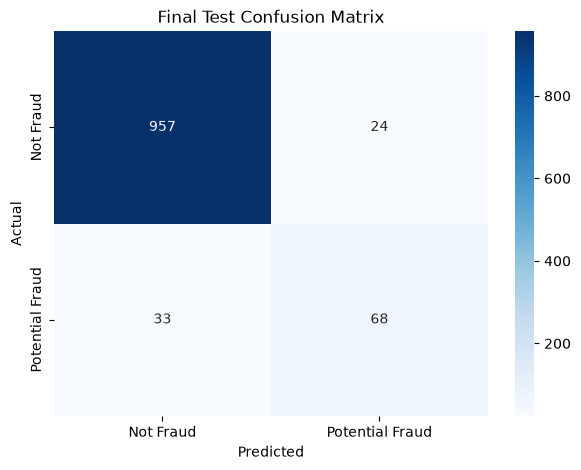

,Feature,Importance
0,InscClaimAmtReimbursed_sum,0.158170
10,HospitalStay_max,0.153004
12,ClaimDuration_max,0.129041
4,DeductibleAmtPaid_sum,0.098500
2,InscClaimAmtReimbursed_max,0.070862
14,ChronicCount_sum,0.063874
9,HospitalStay_mean,0.059915
6,ClaimID_count,0.054626
7,Age_mean,0.040181
1,InscClaimAmtReimbursed_mean,0.034192


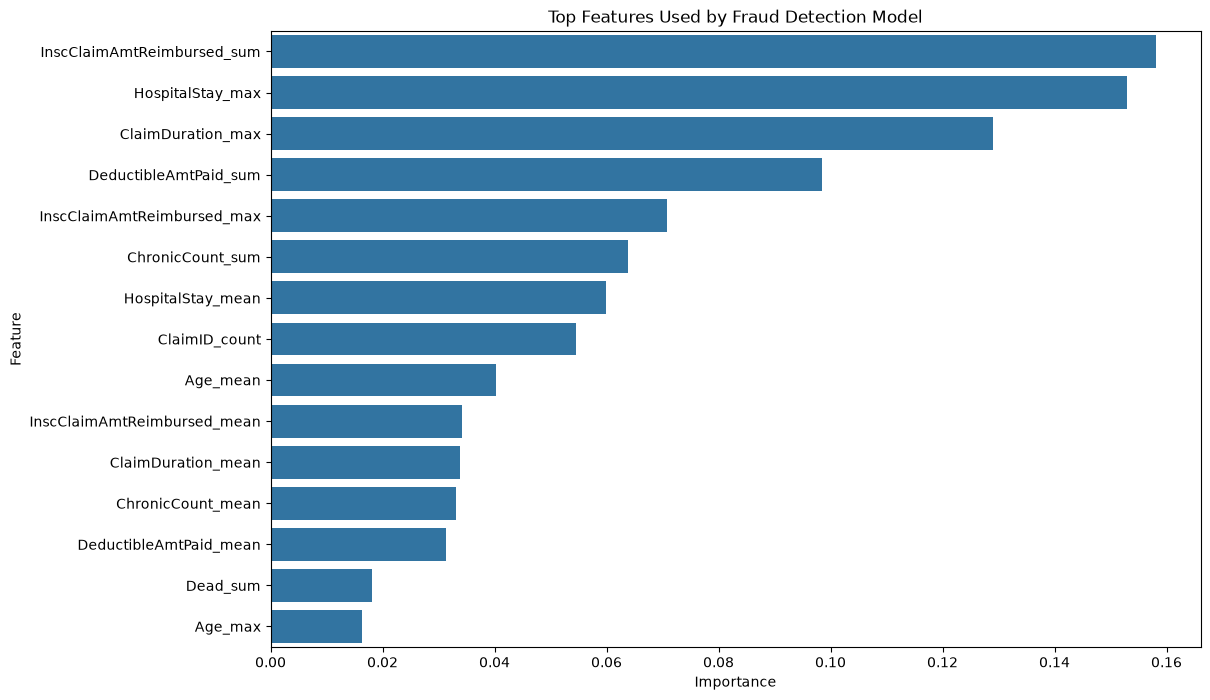

In [58]:
cm=confusion_matrix(y_test,test_predictions)
plt.figure(figsize=(7,5)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Not Fraud","Potential Fraud"],yticklabels=["Not Fraud","Potential Fraud"]); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Final Test Confusion Matrix"); plt.show()
importance=pd.DataFrame({"Feature":X.columns,"Importance":best_model.feature_importances_}).sort_values("Importance",ascending=False)
display(importance.head(20))
plt.figure(figsize=(12,8)); sns.barplot(data=importance.head(15),x="Importance",y="Feature"); plt.title("Top Features Used by Fraud Detection Model"); plt.show()


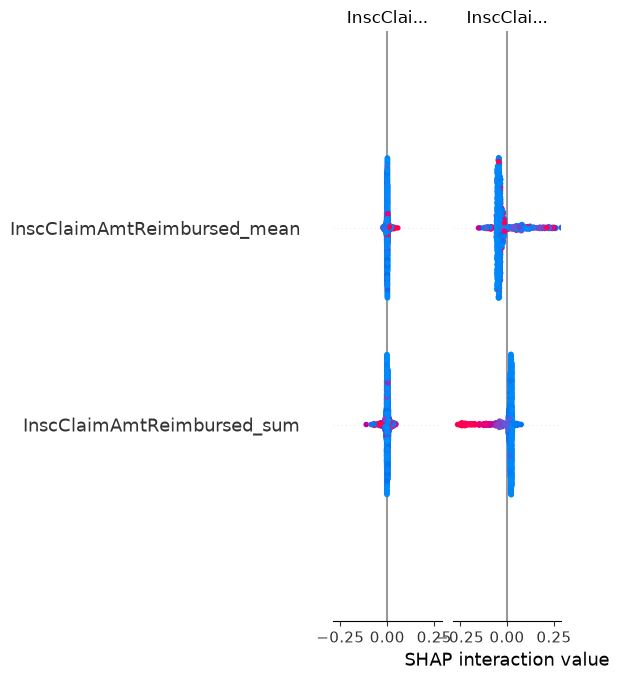

In [59]:
explainer=shap.TreeExplainer(best_model)
shap_values=explainer.shap_values(X_test)
shap_values_plot=shap_values[1] if isinstance(shap_values,list) else shap_values
shap.summary_plot(shap_values_plot,X_test)


In [60]:
production_artifact={"model":best_model,"features":list(X.columns),"threshold":best_threshold,"model_type":"RandomForestClassifier","model_version":"2.1","training_random_state":42,"metrics":{k.lower():float(v) for k,v in final_metrics.items()}}
model_path=MODEL_DIR/"fraud_pipeline.pkl"
joblib.dump(production_artifact,model_path)
print("Production model saved successfully.")
print(model_path)


Production model saved successfully.
/Users/anupgouda/Desktop/Healthcare-Fraud-Detection/models/fraud_pipeline.pkl


In [61]:
loaded_artifact=joblib.load(model_path)
print("Model loaded successfully.")
print("Model type:",type(loaded_artifact["model"]).__name__)
print("Version:",loaded_artifact["model_version"])
print("Threshold:",loaded_artifact["threshold"])
print("Features:",len(loaded_artifact["features"]))
print(json.dumps(loaded_artifact["metrics"],indent=2))
loaded_prob=loaded_artifact["model"].predict_proba(X_test[loaded_artifact["features"]])[:,1]
loaded_pred=(loaded_prob>=loaded_artifact["threshold"]).astype(int)
print("Reloaded artifact prediction test passed:",len(loaded_pred)==len(y_test))


Model loaded successfully.
Model type: RandomForestClassifier
Version: 2.1
Threshold: 0.4500000000000001
Features: 16
{
  "accuracy": 0.9473197781885397,
  "precision": 0.7391304347826086,
  "recall": 0.6732673267326733,
  "f1": 0.7046632124352331,
  "roc_auc": 0.9673297604989856,
  "pr_auc": 0.7864223610772801
}
Reloaded artifact prediction test passed: True


In [62]:
print("="*70)
print("HEALTHCARE PROVIDER FRAUD DETECTION")
print("="*70)
print(f"Providers analyzed : {len(dataset):,}")
print(f"Features used      : {X.shape[1]}")
print(f"Training           : {len(X_train):,}")
print(f"Validation         : {len(X_val):,}")
print(f"Test               : {len(X_test):,}")
print("Model              :",type(best_model).__name__)
print("Version            :",production_artifact["model_version"])
print("Threshold          :",best_threshold)
for metric,value in final_metrics.items(): print(f"{metric:10}: {value:.4f}")
print("Model artifact     :",model_path)
print("PIPELINE COMPLETED SUCCESSFULLY")


HEALTHCARE PROVIDER FRAUD DETECTION
Providers analyzed : 5,410
Features used      : 16
Training           : 3,462
Validation         : 866
Test               : 1,082
Model              : RandomForestClassifier
Version            : 2.1
Threshold          : 0.4500000000000001
Accuracy  : 0.9473
Precision : 0.7391
Recall    : 0.6733
F1        : 0.7047
ROC_AUC   : 0.9673
PR_AUC    : 0.7864
Model artifact     : /Users/anupgouda/Desktop/Healthcare-Fraud-Detection/models/fraud_pipeline.pkl
PIPELINE COMPLETED SUCCESSFULLY
